# Retail Sales Data Analysis & Business Insights

### Using Python, Pandas, Matplotlib and Seaborn

**Dataset:** UCI Online Retail Dataset

---

## Project Overview

This project analyzes retail transaction data to identify sales trends,
product performance, customer behavior, and geographical patterns.

The analysis includes data cleaning, exploratory data analysis,
statistical analysis, and data visualization.

## Dataset

The UCI Online Retail dataset contains transactional information
from a UK-based online retailer.

The dataset includes invoice information, product codes,
product descriptions, quantities, invoice dates, unit prices,
customer IDs, and countries.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving online+retail.zip to online+retail.zip


In [5]:
import zipfile
import os

zip_file = "online+retail.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("retail_data")

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [9]:
os.listdir("retail_data")

['Online Retail.xlsx']

In [10]:
import pandas as pd

file_path = "retail_data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df.shape

(541909, 8)

In [13]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [15]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


In [17]:
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_data

,Missing Values,Percentage (%)
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


In [18]:
df[df['Description'].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [19]:
df[df['Description'].isnull()][
    ['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
].head(10)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [20]:
df[df['Description'].isnull()][
    ['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate',
     'UnitPrice', 'CustomerID', 'Country']
].head(10)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [21]:
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]

print("Cancelled transactions:", len(cancelled))

Cancelled transactions: 9288


In [22]:
cancelled.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [23]:
cancelled['Quantity'].describe()

,Quantity
count,9288.000000
mean,-29.885228
std,1145.786965
min,-80995.000000
25%,-6.000000
50%,-2.000000
75%,-1.000000
max,-1.000000


In [24]:
print("Cancelled transactions:", len(cancelled))

Cancelled transactions: 9288


##  Data Cleaning

The dataset was cleaned using the following steps:

- Missing product descriptions were removed.
- Cancelled transactions were identified and excluded from sales analysis.
- Duplicate records were removed.
- Transactions with non-positive quantities were excluded.
- Transactions with non-positive unit prices were excluded.
- Text fields were standardized.
- A Sales column was calculated as Quantity × UnitPrice.

CustomerID values were not artificially filled because CustomerID
is an identifier rather than a numerical measurement.

In [25]:
# Create a copy of the original dataset
clean_df = df.copy()

# Remove rows where product description is missing
clean_df = clean_df.dropna(subset=['Description'])

# Remove cancelled transactions
clean_df = clean_df[
    ~clean_df['InvoiceNo'].astype(str).str.startswith('C')
]

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 541909
Cleaned rows: 531167
Rows removed: 10742


In [26]:
print("Missing descriptions:", clean_df['Description'].isnull().sum())
print("Cancelled transactions:",
      clean_df['InvoiceNo'].astype(str).str.startswith('C').sum())

Missing descriptions: 0
Cancelled transactions: 0


## Dataset Overview

Before cleaning the dataset, its structure, dimensions, columns,
data types, missing values, and duplicate records were examined.

In [27]:
clean_df.shape

(531167, 8)

In [28]:
print("Zero or negative Quantity:",
      (clean_df['Quantity'] <= 0).sum())

print("Zero or negative UnitPrice:",
      (clean_df['UnitPrice'] <= 0).sum())

Zero or negative Quantity: 474
Zero or negative UnitPrice: 1063


In [29]:
clean_df[clean_df['Quantity'] <= 0][
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,NaN,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom
21338,538072,22423,faulty,-13,2010-12-09 14:10:00,0.0,NaN,United Kingdom
21518,538090,20956,?,-723,2010-12-09 14:48:00,0.0,NaN,United Kingdom
22296,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom
22297,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom
42564,540010,22501,reverse 21/5/10 adjustment,-100,2011-01-04 11:13:00,0.0,NaN,United Kingdom
42566,540012,22502,reverse 21/5/10 adjustment,-100,2011-01-04 11:14:00,0.0,NaN,United Kingdom


In [30]:
clean_df[clean_df['Quantity'] <= 0]['Quantity'].value_counts().sort_index()

,count
Quantity,
-9600,2
-9058,1
-5368,1
-4830,1
-3100,1
...,...
-5,6
-4,6
-3,4


In [31]:
clean_df[clean_df['UnitPrice'] <= 0][
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,NaN,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,2010-12-07 11:48:00,0.0,NaN,United Kingdom


In [32]:
duplicate_count = clean_df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 5231


In [33]:
clean_df[clean_df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [34]:
print("Number of unique countries:", clean_df['Country'].nunique())

print("\nCountry names:")
print(sorted(clean_df['Country'].unique()))

Number of unique countries: 38

Country names:
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong', 'Iceland', 'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified']


In [35]:
# Create a fresh copy of the original dataset
clean_df = df.copy()

print("Starting rows:", len(clean_df))

Starting rows: 541909


In [36]:
clean_df = clean_df.dropna(subset=['Description'])

In [37]:
clean_df = clean_df[
    ~clean_df['InvoiceNo'].astype(str).str.startswith('C')
]

In [38]:
clean_df = clean_df.drop_duplicates()

In [39]:
clean_df = clean_df[
    (clean_df['Quantity'] > 0) &
    (clean_df['UnitPrice'] > 0)
]

In [40]:
clean_df['Description'] = clean_df['Description'].str.strip()
clean_df['Country'] = clean_df['Country'].str.strip()

In [41]:
clean_df['Country'] = clean_df['Country'].str.title()

In [42]:
clean_df['Sales'] = clean_df['Quantity'] * clean_df['UnitPrice']

In [43]:
print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 541909
Cleaned rows: 524878
Rows removed: 17031


In [44]:
print("\nMissing values:")
print(clean_df.isnull().sum())


Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Sales               0
dtype: int64


In [45]:
print("\nDuplicate records:", clean_df.duplicated().sum())


Duplicate records: 0


In [46]:
clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [47]:
print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 541909
Cleaned rows: 524878
Rows removed: 17031


In [48]:
print("Original dataset:", df.shape)
print("Cleaned dataset:", clean_df.shape)

Original dataset: (541909, 8)
Cleaned dataset: (524878, 9)


In [49]:
clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [50]:
# ==============================
# KEY BUSINESS STATISTICS
# ==============================

total_sales = clean_df['Sales'].sum()
total_quantity = clean_df['Quantity'].sum()
average_sales = clean_df['Sales'].mean()
average_quantity = clean_df['Quantity'].mean()
number_of_transactions = clean_df['InvoiceNo'].nunique()
number_of_products = clean_df['StockCode'].nunique()
number_of_customers = clean_df['CustomerID'].nunique()
number_of_countries = clean_df['Country'].nunique()

print("========== RETAIL SALES KPIs ==========")
print(f"Total Sales          : £{total_sales:,.2f}")
print(f"Total Quantity Sold  : {total_quantity:,}")
print(f"Average Sales/Row    : £{average_sales:,.2f}")
print(f"Average Quantity/Row : {average_quantity:.2f}")
print(f"Number of Orders     : {number_of_transactions:,}")
print(f"Number of Products   : {number_of_products:,}")
print(f"Number of Customers  : {number_of_customers:,}")
print(f"Number of Countries  : {number_of_countries:,}")

========== RETAIL SALES KPIs ==========
Total Sales          : £10,642,110.80
Total Quantity Sold  : 5,572,420
Average Sales/Row    : £20.28
Average Quantity/Row : 10.62
Number of Orders     : 19,960
Number of Products   : 3,922
Number of Customers  : 4,338
Number of Countries  : 38


In [51]:
average_order_value = total_sales / number_of_transactions

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £533.17


In [52]:
kpi = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Quantity Sold',
        'Number of Orders',
        'Number of Products',
        'Number of Customers',
        'Number of Countries',
        'Average Order Value'
    ],
    'Value': [
        total_sales,
        total_quantity,
        number_of_transactions,
        number_of_products,
        number_of_customers,
        number_of_countries,
        average_order_value
    ]
})

kpi

,Metric,Value
0,Total Sales,1.064211e+07
1,Total Quantity Sold,5.572420e+06
2,Number of Orders,1.996000e+04
3,Number of Products,3.922000e+03
4,Number of Customers,4.338000e+03
5,Number of Countries,3.800000e+01
6,Average Order Value,5.331719e+02


In [53]:
clean_df[['Quantity', 'UnitPrice', 'Sales']].describe()

,Quantity,UnitPrice,Sales
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [54]:
clean_df['Sales'].describe()

,Sales
count,524878.000000
mean,20.275399
std,271.693566
min,0.001000
25%,3.900000
50%,9.920000
75%,17.700000
max,168469.600000


In [55]:
clean_df.nlargest(10, 'Sales')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Sales', 'Country']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Sales,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,Netherlands


In [56]:
clean_df.nlargest(10, 'Sales')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'InvoiceDate', 'UnitPrice',
     'CustomerID', 'Country', 'Sales']
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00


In [57]:
clean_df.nlargest(10, 'Quantity')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Sales',
     'CustomerID', 'Country']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Sales,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,16308.0,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,16754.0,United Kingdom


In [58]:
clean_df.nlargest(10, 'UnitPrice')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Sales',
     'CustomerID', 'Country']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Sales,CustomerID,Country
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
297723,562955,DOT,DOTCOM POSTAGE,1,4505.17,4505.17,NaN,United Kingdom
268028,560373,M,Manual,1,4287.63,4287.63,NaN,United Kingdom
422351,573077,M,Manual,1,4161.06,4161.06,12536.0,France
422376,573080,M,Manual,1,4161.06,4161.06,12536.0,France
406406,571751,M,Manual,1,3949.32,3949.32,12744.0,Singapore
374542,569382,M,Manual,1,3155.95,3155.95,15502.0,United Kingdom
347948,567353,M,Manual,1,2653.95,2653.95,NaN,Hong Kong


In [59]:
average_order_value = total_sales / number_of_transactions

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £533.17


In [60]:
clean_df.nlargest(10, 'UnitPrice')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Sales',
     'CustomerID', 'Country']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Sales,CustomerID,Country
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
297723,562955,DOT,DOTCOM POSTAGE,1,4505.17,4505.17,NaN,United Kingdom
268028,560373,M,Manual,1,4287.63,4287.63,NaN,United Kingdom
422351,573077,M,Manual,1,4161.06,4161.06,12536.0,France
422376,573080,M,Manual,1,4161.06,4161.06,12536.0,France
406406,571751,M,Manual,1,3949.32,3949.32,12744.0,Singapore
374542,569382,M,Manual,1,3155.95,3155.95,15502.0,United Kingdom
347948,567353,M,Manual,1,2653.95,2653.95,NaN,Hong Kong


In [61]:
# Extract time-related information

clean_df['Year'] = clean_df['InvoiceDate'].dt.year
clean_df['Month'] = clean_df['InvoiceDate'].dt.month
clean_df['Month_Name'] = clean_df['InvoiceDate'].dt.month_name()

In [62]:
clean_df[['InvoiceDate', 'Year', 'Month', 'Month_Name']].head()

,InvoiceDate,Year,Month,Month_Name
0,2010-12-01 08:26:00,2010,12,December
1,2010-12-01 08:26:00,2010,12,December
2,2010-12-01 08:26:00,2010,12,December
3,2010-12-01 08:26:00,2010,12,December
4,2010-12-01 08:26:00,2010,12,December


In [63]:
yearly_sales = clean_df.groupby('Year')['Sales'].sum()

yearly_sales

,Sales
Year,
2010,821452.730
2011,9820658.074


In [64]:
monthly_sales = clean_df.groupby(
    clean_df['InvoiceDate'].dt.to_period('M')
)['Sales'].sum()

monthly_sales

,Sales
InvoiceDate,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

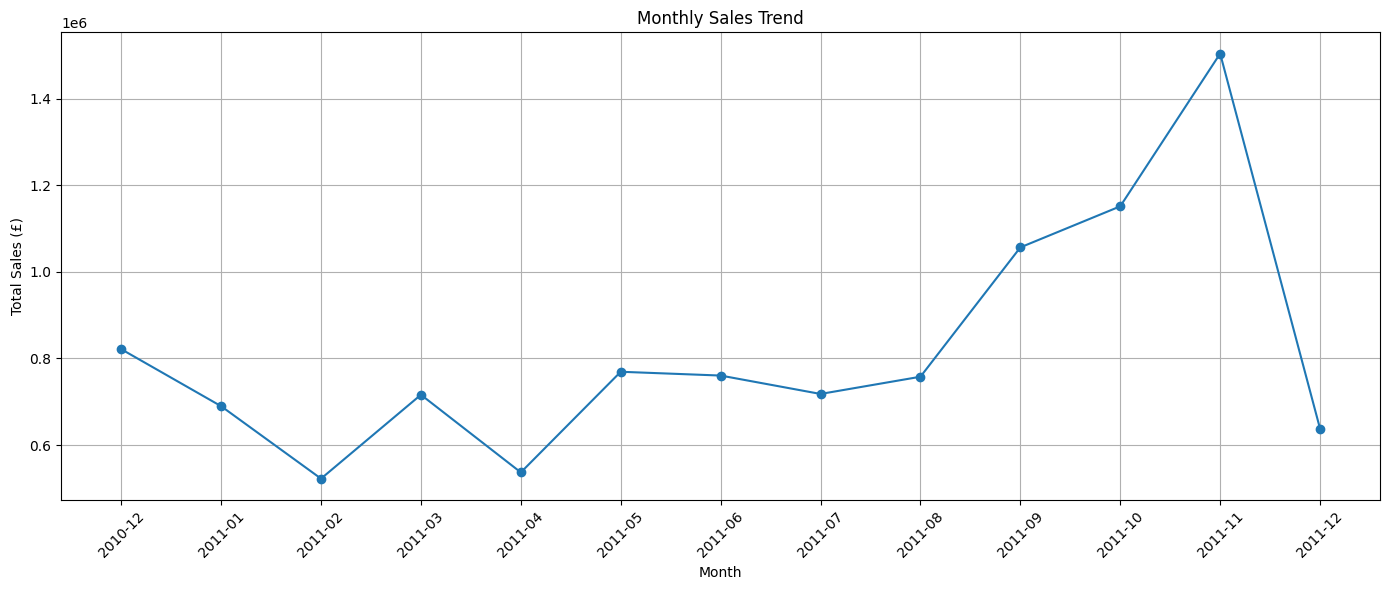

In [66]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [67]:
highest_sales_month = monthly_sales.idxmax()
highest_sales_value = monthly_sales.max()

lowest_sales_month = monthly_sales.idxmin()
lowest_sales_value = monthly_sales.min()

print("Highest Sales Month:", highest_sales_month)
print(f"Highest Sales: £{highest_sales_value:,.2f}")

print("\nLowest Sales Month:", lowest_sales_month)
print(f"Lowest Sales: £{lowest_sales_value:,.2f}")

Highest Sales Month: 2011-11
Highest Sales: £1,503,866.78

Lowest Sales Month: 2011-02
Lowest Sales: £522,545.56


In [68]:
monthly_growth = monthly_sales.pct_change() * 100

monthly_growth

,Sales
InvoiceDate,
2010-12,NaN
2011-01,-16.025404
2011-02,-24.248077
2011-03,37.062740
2011-04,-25.026941
2011-05,43.266620
2011-06,-1.137351
2011-07,-5.584256
2011-08,5.537750


In [69]:
clean_df['Year'] = clean_df['InvoiceDate'].dt.year
clean_df['Month'] = clean_df['InvoiceDate'].dt.month
clean_df['Month_Name'] = clean_df['InvoiceDate'].dt.month_name()

In [70]:
yearly_sales = clean_df.groupby('Year')['Sales'].sum()
yearly_sales

,Sales
Year,
2010,821452.730
2011,9820658.074


In [71]:
monthly_sales = clean_df.groupby(
    clean_df['InvoiceDate'].dt.to_period('M')
)['Sales'].sum()

monthly_sales

,Sales
InvoiceDate,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


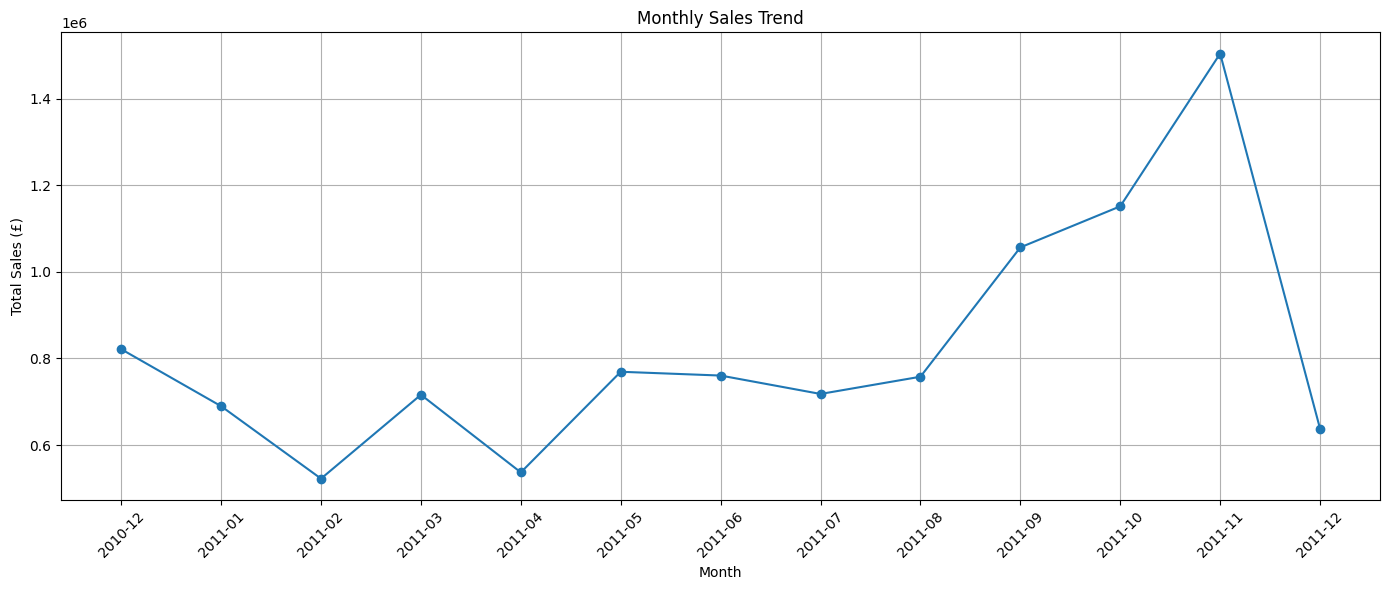

In [72]:
# Monthly Sales Line Chart

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [73]:
# Find the highest and lowest sales months

highest_sales_month = monthly_sales.idxmax()
highest_sales_value = monthly_sales.max()

lowest_sales_month = monthly_sales.idxmin()
lowest_sales_value = monthly_sales.min()

print("Highest Sales Month:", highest_sales_month)
print(f"Highest Sales: £{highest_sales_value:,.2f}")

print("\nLowest Sales Month:", lowest_sales_month)
print(f"Lowest Sales: £{lowest_sales_value:,.2f}")

Highest Sales Month: 2011-11
Highest Sales: £1,503,866.78

Lowest Sales Month: 2011-02
Lowest Sales: £522,545.56


In [74]:
monthly_growth = monthly_sales.pct_change() * 100

monthly_growth

,Sales
InvoiceDate,
2010-12,NaN
2011-01,-16.025404
2011-02,-24.248077
2011-03,37.062740
2011-04,-25.026941
2011-05,43.266620
2011-06,-1.137351
2011-07,-5.584256
2011-08,5.537750


In [75]:
largest_increase_month = monthly_growth.idxmax()
largest_increase = monthly_growth.max()

largest_decrease_month = monthly_growth.idxmin()
largest_decrease = monthly_growth.min()

print("Largest Monthly Increase:")
print(largest_increase_month, f"({largest_increase:.2f}%)")

print("\nLargest Monthly Decrease:")
print(largest_decrease_month, f"({largest_decrease:.2f}%)")

Largest Monthly Increase:
2011-05 (43.27%)

Largest Monthly Decrease:
2011-12 (-57.59%)


In [76]:
# Total sales generated by each product

product_sales = (
    clean_df.groupby(['StockCode', 'Description'])['Sales']
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

,,Sales
StockCode,Description,
DOT,DOTCOM POSTAGE,206248.77
22423,REGENCY CAKESTAND 3 TIER,174156.54
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
47566,PARTY BUNTING,99445.23
85099B,JUMBO BAG RED RETROSPOT,94159.81
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POST,POSTAGE,78101.88
M,Manual,77750.27


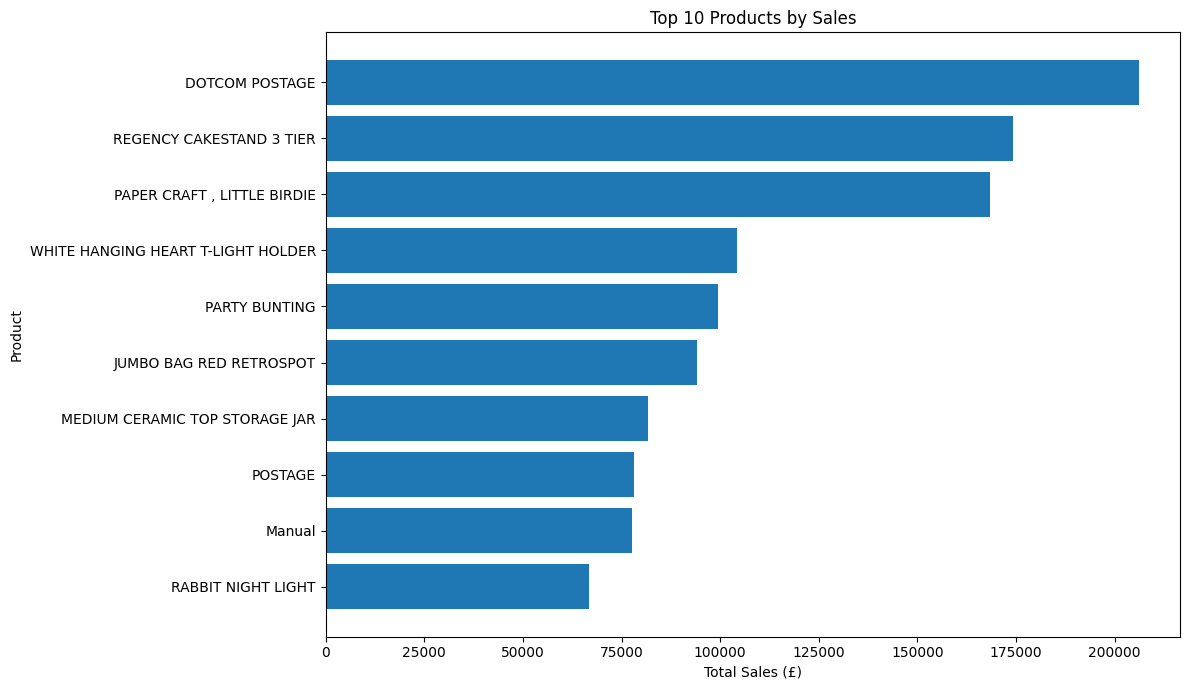

In [77]:
# Top 10 Products by Sales

top_products = product_sales.head(10).sort_values()

plt.figure(figsize=(12, 7))

plt.barh(
    top_products.index.get_level_values('Description'),
    top_products.values
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales (£)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [78]:
product_quantity = (
    clean_df.groupby(['StockCode', 'Description'])['Quantity']
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

,,Quantity
StockCode,Description,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
85099B,JUMBO BAG RED RETROSPOT,48371
85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580
22197,POPCORN HOLDER,36749
21212,PACK OF 72 RETROSPOT CAKE CASES,36396
84879,ASSORTED COLOUR BIRD ORNAMENT,36362
23084,RABBIT NIGHT LIGHT,30739


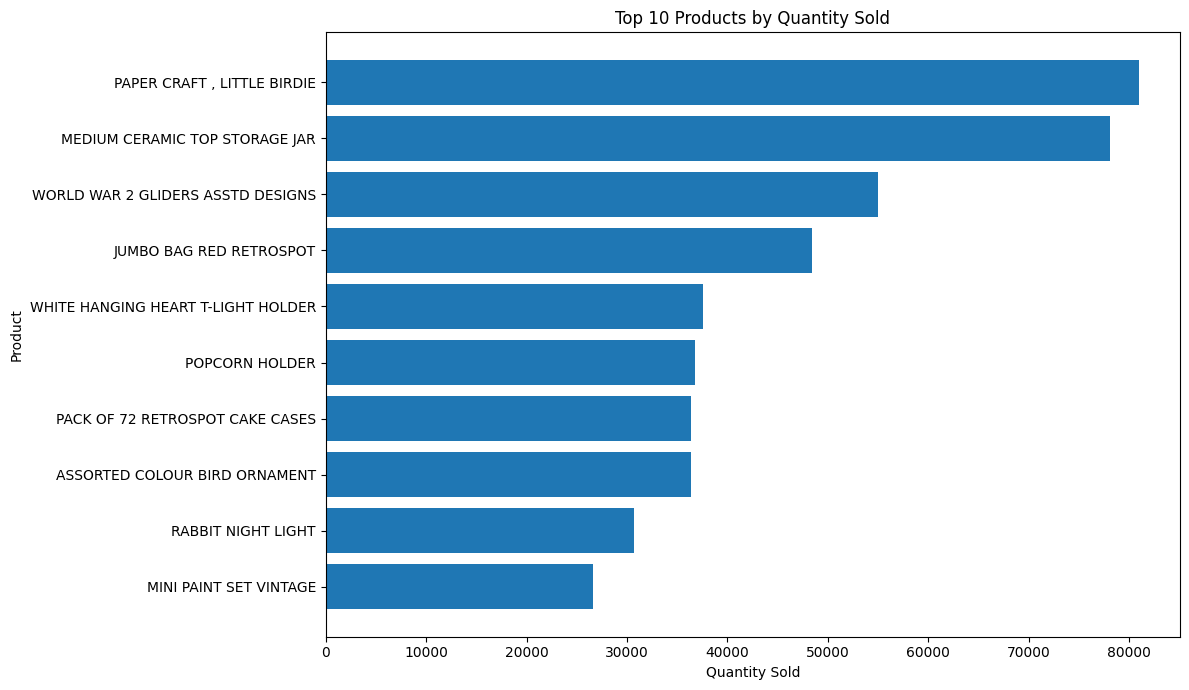

In [79]:
top_quantity_products = product_quantity.head(10).sort_values()

plt.figure(figsize=(12, 7))

plt.barh(
    top_quantity_products.index.get_level_values('Description'),
    top_quantity_products.values
)

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [80]:
product_analysis = (
    clean_df
    .groupby(['StockCode', 'Description'])
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Average_Unit_Price=('UnitPrice', 'mean'),
        Number_of_Orders=('InvoiceNo', 'nunique')
    )
    .sort_values('Total_Sales', ascending=False)
)

product_analysis.head(10)

,,Total_Sales,Total_Quantity,Average_Unit_Price,Number_of_Orders
StockCode,Description,,,,
DOT,DOTCOM POSTAGE,206248.77,706,292.137068,706
22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,13.983936,1988
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,2.080000,1
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,3.116159,2189
47566,PARTY BUNTING,99445.23,18283,5.797928,1685
85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2.486197,2089
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,1.468480,247
POST,POSTAGE,78101.88,3150,31.076581,1126
M,Manual,77750.27,6984,234.489652,289


In [81]:
most_ordered_products = product_analysis.sort_values(
    'Number_of_Orders',
    ascending=False
)

most_ordered_products.head(10)

,,Total_Sales,Total_Quantity,Average_Unit_Price,Number_of_Orders
StockCode,Description,,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,3.116159,2189
85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2.486197,2089
22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,13.983936,1988
47566,PARTY BUNTING,99445.23,18283,5.797928,1685
20725,LUNCH BAG RED RETROSPOT,35572.36,19232,2.131853,1564
84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1.722575,1455
22720,SET OF 3 CAKE TINS PANTRY DESIGN,38108.89,7483,5.833714,1385
21212,PACK OF 72 RETROSPOT CAKE CASES,21246.45,36396,0.761206,1320
20727,LUNCH BAG BLACK SKULL.,22346.96,12195,2.107786,1273


In [82]:
special_items = clean_df[
    clean_df['Description'].str.contains(
        'POSTAGE|FEE|ADJUST|MANUAL|BANK CHARGES|DAMAGE|CHECK',
        case=False,
        na=False
    )
]

print("Special transaction records:", len(special_items))

Special transaction records: 5853


In [83]:
merchandise_df = clean_df[
    ~clean_df['Description'].str.contains(
        'POSTAGE|FEE|ADJUST|MANUAL|BANK CHARGES|DAMAGE|CHECK',
        case=False,
        na=False
    )
].copy()

print("Original cleaned records:", len(clean_df))
print("Merchandise records:", len(merchandise_df))

Original cleaned records: 524878
Merchandise records: 519025


In [84]:
merchandise_product_sales = (
    merchandise_df.groupby(['StockCode', 'Description'])['Sales']
    .sum()
    .sort_values(ascending=False)
)

merchandise_product_sales.head(10)

,,Sales
StockCode,Description,
22423,REGENCY CAKESTAND 3 TIER,174156.54
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
47566,PARTY BUNTING,99445.23
85099B,JUMBO BAG RED RETROSPOT,94159.81
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
23084,RABBIT NIGHT LIGHT,66870.03
22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62


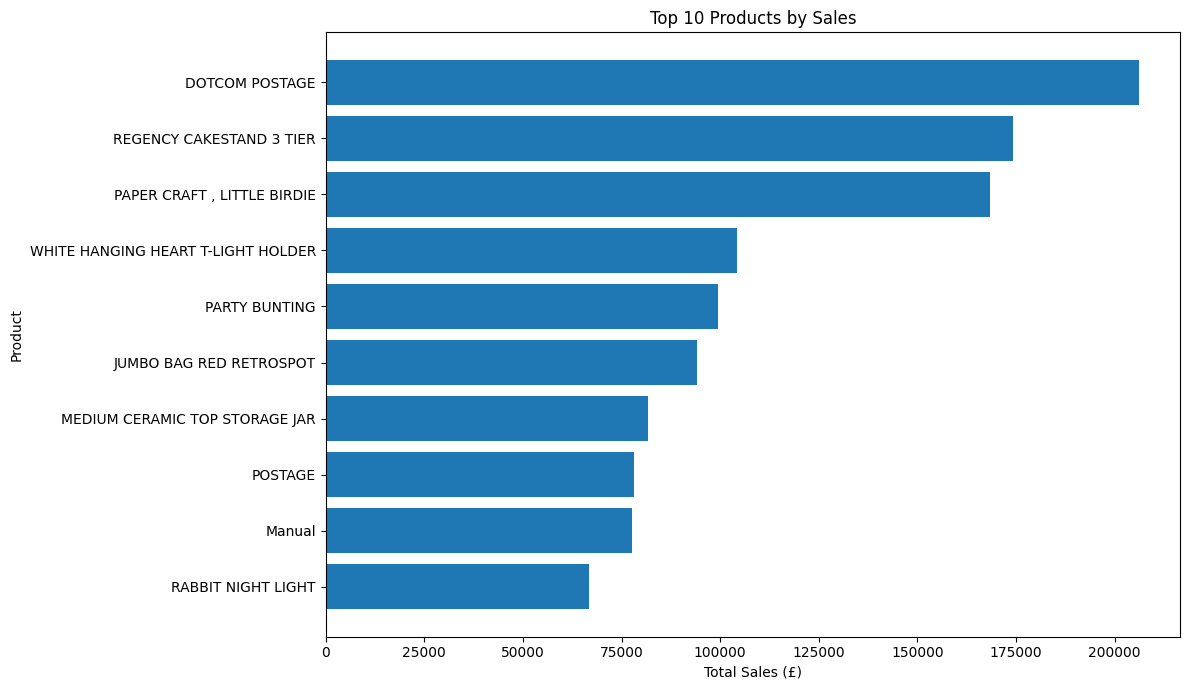

In [86]:
# Top 10 Products by Sales

top_products = product_sales.head(10).sort_values()

plt.figure(figsize=(12, 7))

plt.barh(
    top_products.index.get_level_values('Description'),
    top_products.values
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales (£)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [87]:
special_items = clean_df[
    clean_df['Description'].str.contains(
        'POSTAGE|FEE|ADJUST|MANUAL|BANK CHARGES|DAMAGE|CHECK',
        case=False,
        na=False
    )
]

print("Special transaction records:", len(special_items))

Special transaction records: 5853


In [88]:
merchandise_df = clean_df[
    ~clean_df['Description'].str.contains(
        'POSTAGE|FEE|ADJUST|MANUAL|BANK CHARGES|DAMAGE|CHECK',
        case=False,
        na=False
    )
].copy()

print("Original cleaned records:", len(clean_df))
print("Merchandise records:", len(merchandise_df))

Original cleaned records: 524878
Merchandise records: 519025


In [89]:
merchandise_product_sales = (
    merchandise_df.groupby(['StockCode', 'Description'])['Sales']
    .sum()
    .sort_values(ascending=False)
)

merchandise_product_sales.head(10)

,,Sales
StockCode,Description,
22423,REGENCY CAKESTAND 3 TIER,174156.54
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
47566,PARTY BUNTING,99445.23
85099B,JUMBO BAG RED RETROSPOT,94159.81
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
23084,RABBIT NIGHT LIGHT,66870.03
22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62


In [90]:
# Create dataset for customer-level analysis
customer_df = clean_df.dropna(subset=['CustomerID']).copy()

print("Customer analysis records:", len(customer_df))
print("Unique customers:", customer_df['CustomerID'].nunique())

Customer analysis records: 392692
Unique customers: 4338


In [91]:
customer_analysis = (
    customer_df
    .groupby('CustomerID')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Number_of_Orders=('InvoiceNo', 'nunique'),
        Average_Order_Value=('Sales', 'sum')
    )
)

In [92]:
customer_analysis['Average_Order_Value'] = (
    customer_analysis['Total_Sales'] /
    customer_analysis['Number_of_Orders']
)

In [93]:
customer_analysis.head()

,Total_Sales,Total_Quantity,Number_of_Orders,Average_Order_Value
CustomerID,,,,
12346.0,77183.60,74215,1,77183.600000
12347.0,4310.00,2458,7,615.714286
12348.0,1797.24,2341,4,449.310000
12349.0,1757.55,631,1,1757.550000
12350.0,334.40,197,1,334.400000


In [94]:
top_customers = customer_analysis.sort_values(
    'Total_Sales',
    ascending=False
).head(10)

top_customers

,Total_Sales,Total_Quantity,Number_of_Orders,Average_Order_Value
CustomerID,,,,
14646.0,280206.02,196915,73,3838.438630
18102.0,259657.30,64124,60,4327.621667
17450.0,194390.79,69973,46,4225.886739
16446.0,168472.50,80997,2,84236.250000
14911.0,143711.17,80240,201,714.980945
12415.0,124914.53,77374,21,5948.310952
14156.0,117210.08,57768,55,2131.092364
17511.0,91062.38,64549,31,2937.496129
16029.0,80850.84,40108,63,1283.346667


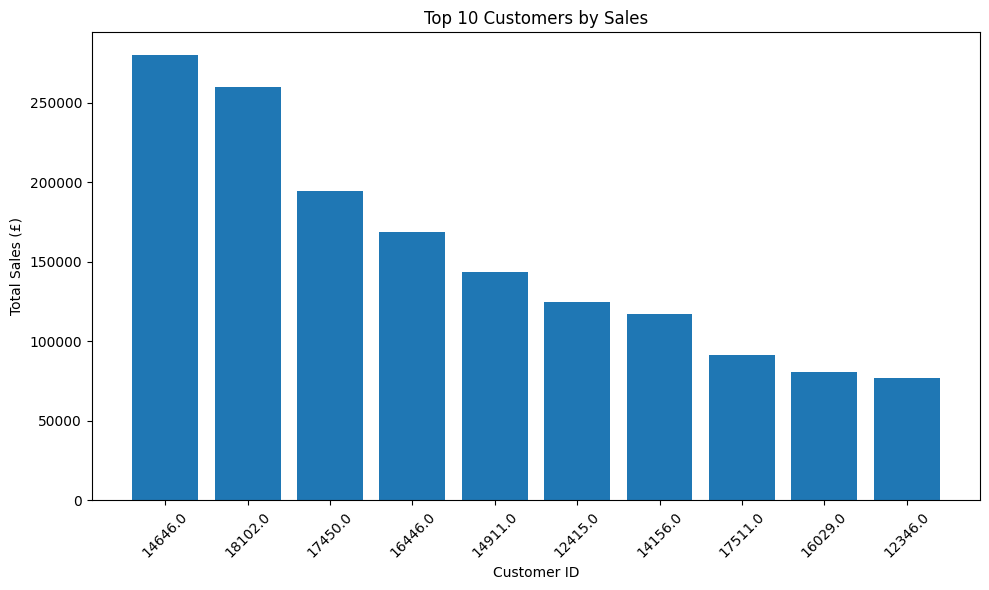

In [95]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_customers.index.astype(str),
    top_customers['Total_Sales']
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales (£)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [96]:
most_frequent_customers = customer_analysis.sort_values(
    'Number_of_Orders',
    ascending=False
).head(10)

most_frequent_customers

,Total_Sales,Total_Quantity,Number_of_Orders,Average_Order_Value
CustomerID,,,,
12748.0,33053.19,25287,209,158.149234
14911.0,143711.17,80240,201,714.980945
17841.0,40519.84,22834,124,326.772903
13089.0,58762.08,31025,97,605.794639
14606.0,12076.15,6187,93,129.851075
15311.0,60632.75,38147,91,666.293956
12971.0,11189.91,9289,86,130.115233
14646.0,280206.02,196915,73,3838.438630
16029.0,80850.84,40108,63,1283.346667


In [97]:
highest_quantity_customers = customer_analysis.sort_values(
    'Total_Quantity',
    ascending=False
).head(10)

highest_quantity_customers

,Total_Sales,Total_Quantity,Number_of_Orders,Average_Order_Value
CustomerID,,,,
14646.0,280206.02,196915,73,3838.438630
16446.0,168472.50,80997,2,84236.250000
14911.0,143711.17,80240,201,714.980945
12415.0,124914.53,77374,21,5948.310952
12346.0,77183.60,74215,1,77183.600000
17450.0,194390.79,69973,46,4225.886739
17511.0,91062.38,64549,31,2937.496129
18102.0,259657.30,64124,60,4327.621667
13694.0,65039.62,63312,50,1300.792400


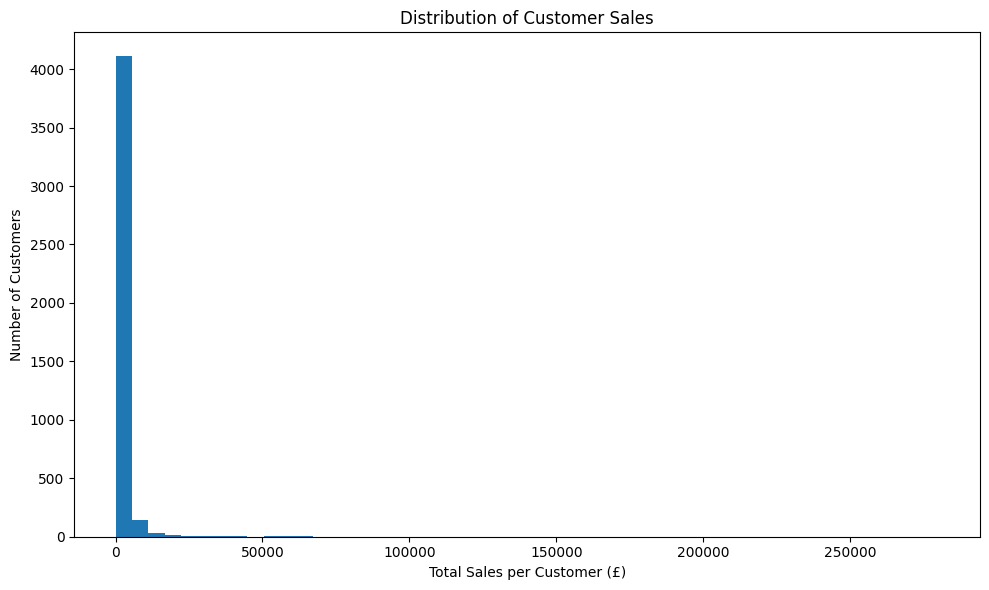

In [98]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_analysis['Total_Sales'],
    bins=50
)

plt.title('Distribution of Customer Sales')
plt.xlabel('Total Sales per Customer (£)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [99]:
country_sales = (
    clean_df.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False)
)

country_sales

,Sales
Country,
United Kingdom,9001744.094
Netherlands,285446.340
Eire,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [100]:
top_countries = country_sales.head(10)

top_countries

,Sales
Country,
United Kingdom,9001744.094
Netherlands,285446.340
Eire,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


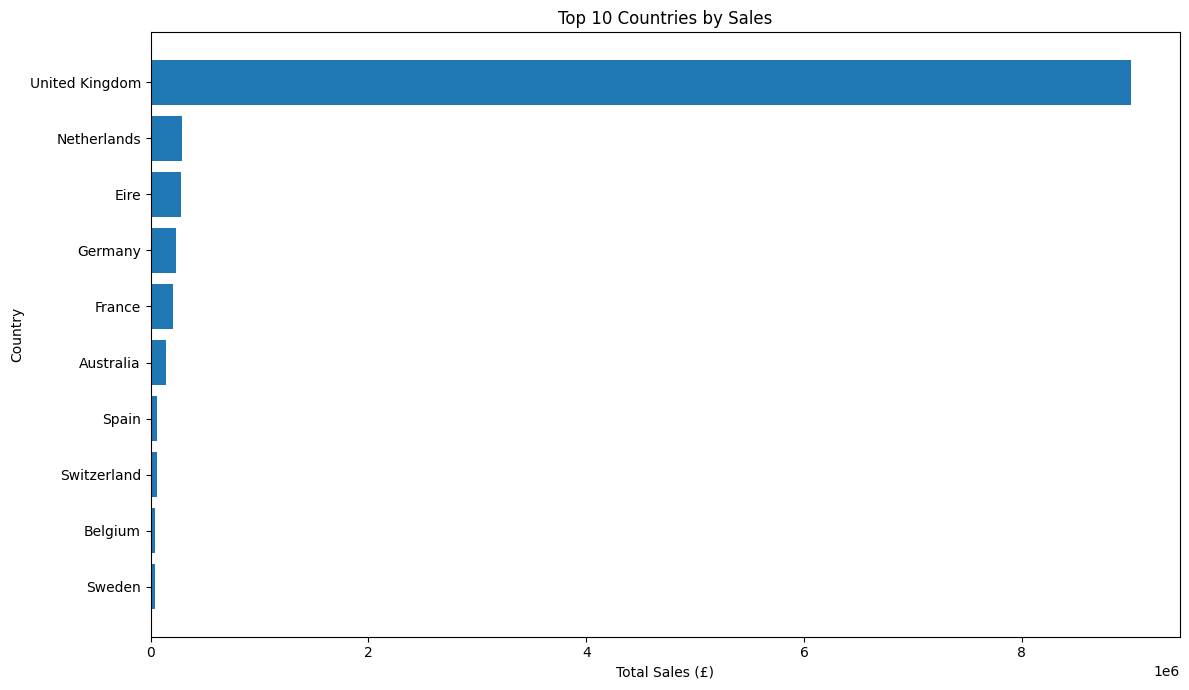

In [101]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_countries.index[::-1],
    top_countries.values[::-1]
)

plt.title('Top 10 Countries by Sales')
plt.xlabel('Total Sales (£)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [102]:
country_quantity = (
    clean_df.groupby('Country')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

country_quantity.head(10)

,Quantity
Country,
United Kingdom,4646906
Netherlands,200361
Eire,147007
Germany,119154
France,112060
Australia,83891
Sweden,36078
Switzerland,30617
Spain,27933


In [103]:
country_analysis = (
    clean_df.groupby('Country')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Number_of_Orders=('InvoiceNo', 'nunique'),
        Number_of_Customers=('CustomerID', 'nunique')
    )
    .sort_values('Total_Sales', ascending=False)
)

country_analysis.head(10)

,Total_Sales,Total_Quantity,Number_of_Orders,Number_of_Customers
Country,,,,
United Kingdom,9001744.094,4646906,18019,3920
Netherlands,285446.340,200361,94,9
Eire,283140.520,147007,288,3
Germany,228678.400,119154,457,94
France,209625.370,112060,392,87
Australia,138453.810,83891,57,9
Spain,61558.560,27933,90,30
Switzerland,57067.600,30617,54,21
Belgium,41196.340,23237,98,25


In [104]:
country_analysis.sort_values(
    'Number_of_Customers',
    ascending=False
).head(10)

,Total_Sales,Total_Quantity,Number_of_Orders,Number_of_Customers
Country,,,,
United Kingdom,9001744.094,4646906,18019,3920
Germany,228678.400,119154,457,94
France,209625.370,112060,392,87
Spain,61558.560,27933,90,30
Belgium,41196.340,23237,98,25
Switzerland,57067.600,30617,54,21
Portugal,33683.050,16231,58,19
Italy,17483.240,8112,38,14
Finland,22546.080,10704,41,12


In [105]:
country_analysis.sort_values(
    'Number_of_Orders',
    ascending=False
).head(10)

,Total_Sales,Total_Quantity,Number_of_Orders,Number_of_Customers
Country,,,,
United Kingdom,9001744.094,4646906,18019,3920
Germany,228678.400,119154,457,94
France,209625.370,112060,392,87
Eire,283140.520,147007,288,3
Belgium,41196.340,23237,98,25
Netherlands,285446.340,200361,94,9
Spain,61558.560,27933,90,30
Portugal,33683.050,16231,58,19
Australia,138453.810,83891,57,9


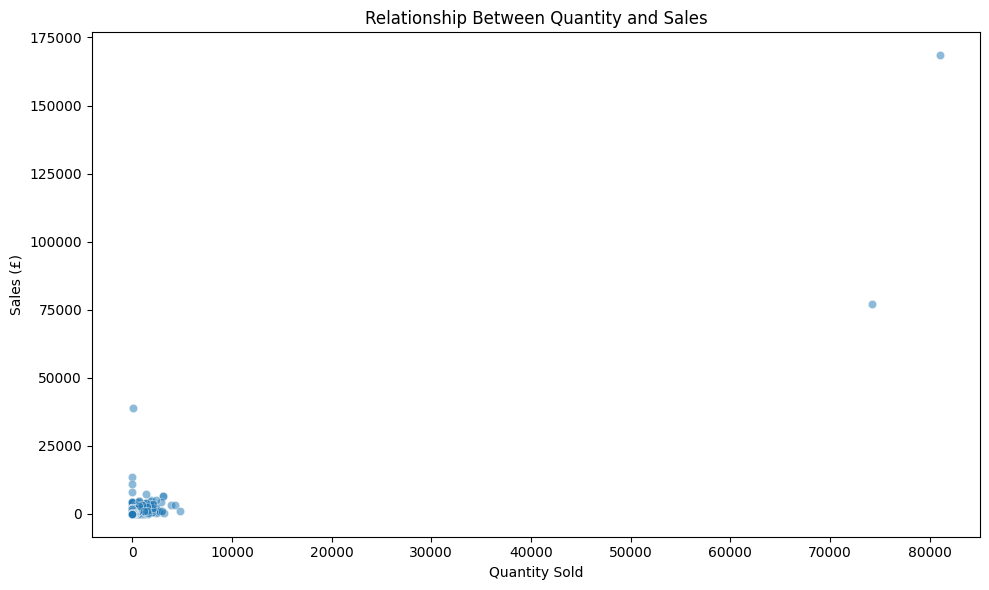

In [106]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x='Quantity',
    y='Sales',
    alpha=0.5
)

plt.title('Relationship Between Quantity and Sales')
plt.xlabel('Quantity Sold')
plt.ylabel('Sales (£)')

plt.tight_layout()
plt.show()

In [107]:
quantity_sales_correlation = clean_df[
    ['Quantity', 'Sales']
].corr().iloc[0, 1]

print(
    f"Correlation between Quantity and Sales: "
    f"{quantity_sales_correlation:.4f}"
)

Correlation between Quantity and Sales: 0.9074


In [108]:
correlation = clean_df[
    ['Quantity', 'UnitPrice', 'Sales']
].corr()

correlation

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Sales,0.907402,0.137381,1.000000


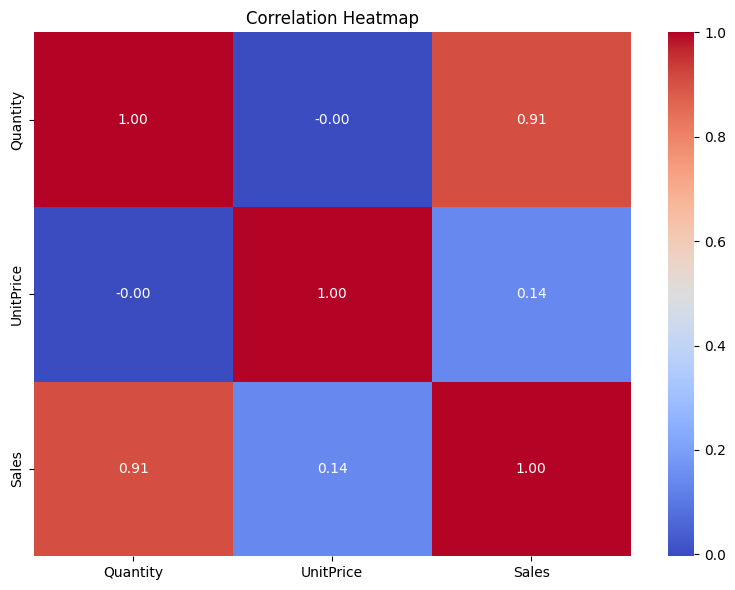

In [109]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [110]:
# Top 10 merchandise products by sales

top_merchandise_sales = (
    merchandise_df.groupby('Description')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_merchandise_sales

,Sales
Description,
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66870.03
PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
ASSORTED COLOUR BIRD ORNAMENT,58927.62


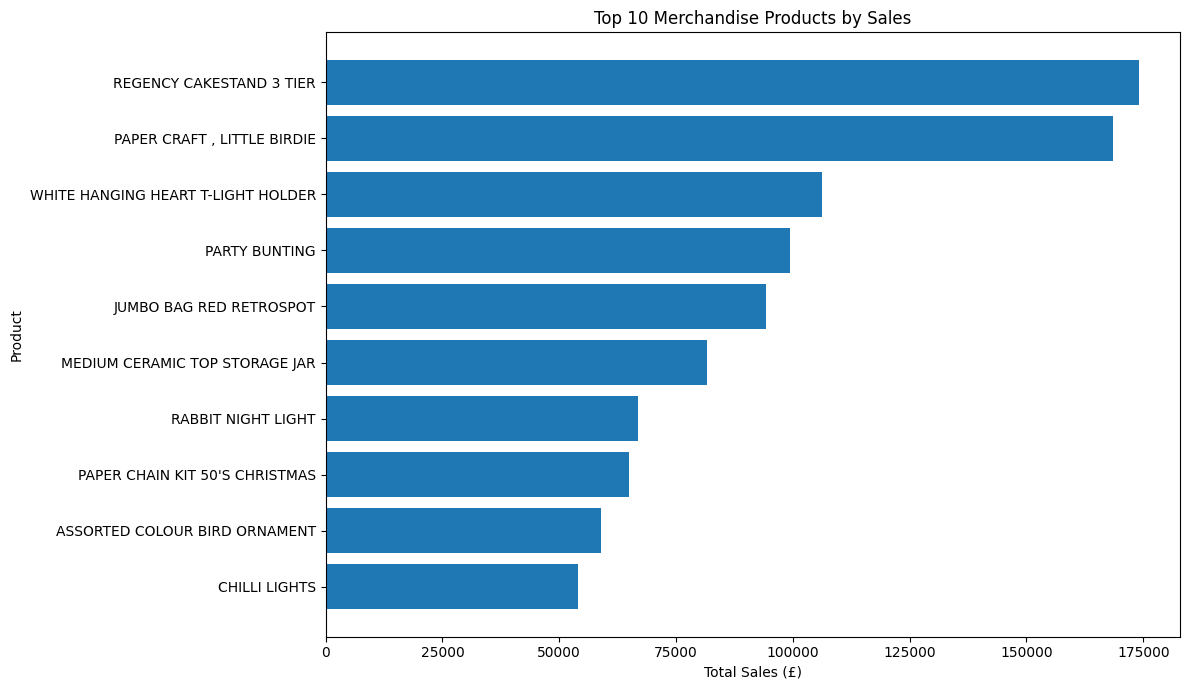

In [111]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_merchandise_sales.index[::-1],
    top_merchandise_sales.values[::-1]
)

plt.title('Top 10 Merchandise Products by Sales')
plt.xlabel('Total Sales (£)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [112]:
top_merchandise_quantity = (
    merchandise_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_merchandise_quantity

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


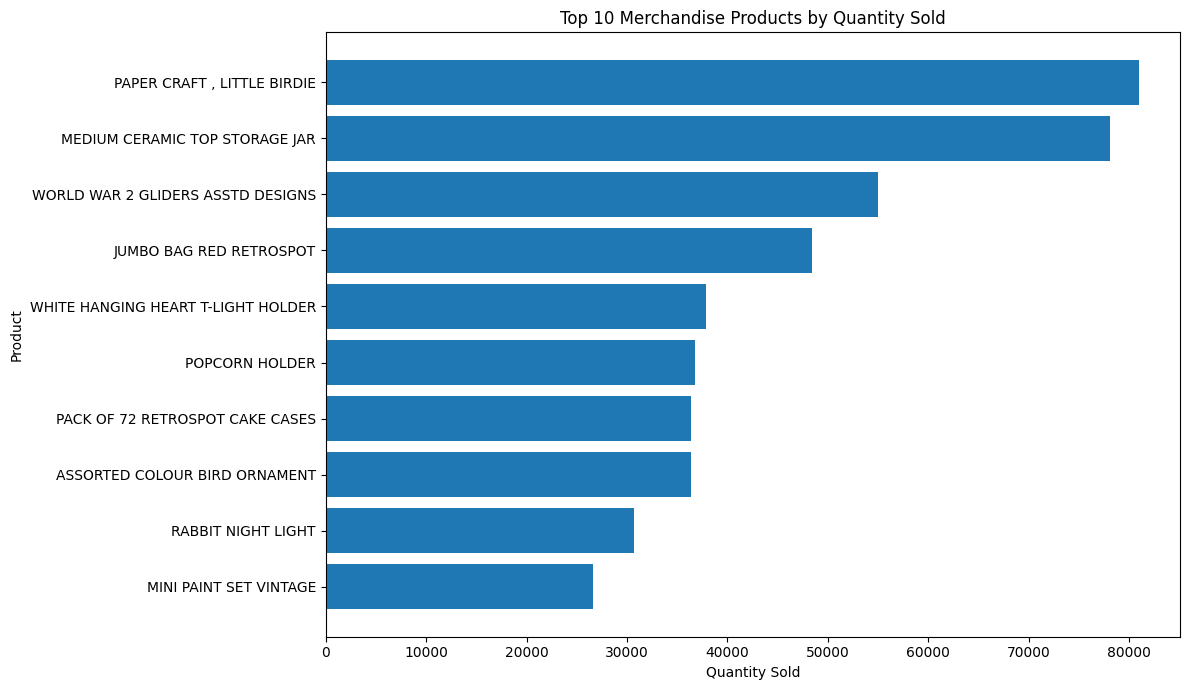

In [113]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_merchandise_quantity.index[::-1],
    top_merchandise_quantity.values[::-1]
)

plt.title('Top 10 Merchandise Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [114]:
# ==========================================
# BUSINESS INSIGHTS SUMMARY
# ==========================================

print("========== BUSINESS INSIGHTS ==========\n")

# 1. Overall performance
print("1. OVERALL PERFORMANCE")
print(f"Total Sales: £{clean_df['Sales'].sum():,.2f}")
print(f"Total Quantity Sold: {clean_df['Quantity'].sum():,}")
print(f"Total Orders: {clean_df['InvoiceNo'].nunique():,}")
print(f"Unique Customers: {clean_df['CustomerID'].nunique():,}")
print(f"Unique Products: {clean_df['StockCode'].nunique():,}")
print(f"Countries Served: {clean_df['Country'].nunique():,}")

# 2. Monthly performance
print("\n2. TIME-BASED PERFORMANCE")

highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print(f"Highest Sales Month: {highest_month}")
print(f"Sales in Highest Month: £{highest_month_sales:,.2f}")

print(f"Lowest Sales Month: {lowest_month}")
print(f"Sales in Lowest Month: £{lowest_month_sales:,.2f}")

# 3. Product performance
print("\n3. PRODUCT PERFORMANCE")

top_product = merchandise_product_sales.idxmax()
top_product_sales = merchandise_product_sales.max()

print(f"Top Product by Sales: {top_product}")
print(f"Sales Generated: £{top_product_sales:,.2f}")

# 4. Country performance
print("\n4. COUNTRY PERFORMANCE")

top_country = country_sales.idxmax()
top_country_sales = country_sales.max()

print(f"Top Country by Sales: {top_country}")
print(f"Sales Generated: £{top_country_sales:,.2f}")

# 5. Customer performance
print("\n5. CUSTOMER PERFORMANCE")

top_customer = customer_analysis['Total_Sales'].idxmax()
top_customer_sales = customer_analysis['Total_Sales'].max()

print(f"Top Customer ID: {int(top_customer)}")
print(f"Customer Sales: £{top_customer_sales:,.2f}")

# 6. Quantity performance
print("\n6. QUANTITY PERFORMANCE")

top_quantity_product = (
    merchandise_df.groupby('Description')['Quantity']
    .sum()
    .idxmax()
)

top_quantity = (
    merchandise_df.groupby('Description')['Quantity']
    .sum()
    .max()
)

print(f"Top Product by Quantity: {top_quantity_product}")
print(f"Quantity Sold: {top_quantity:,}")

# 7. Correlation
print("\n7. SALES AND QUANTITY RELATIONSHIP")

correlation = clean_df[['Quantity', 'Sales']].corr().iloc[0, 1]

print(f"Quantity-Sales Correlation: {correlation:.4f}")

# 8. Customer concentration
print("\n8. CUSTOMER CONCENTRATION")

top_10_customer_sales = customer_analysis.nlargest(
    10, 'Total_Sales'
)['Total_Sales'].sum()

customer_sales_share = (
    top_10_customer_sales /
    customer_analysis['Total_Sales'].sum()
) * 100

print(f"Top 10 Customers' Share of Sales: {customer_sales_share:.2f}%")

========== BUSINESS INSIGHTS ==========

1. OVERALL PERFORMANCE
Total Sales: £10,642,110.80
Total Quantity Sold: 5,572,420
Total Orders: 19,960
Unique Customers: 4,338
Unique Products: 3,922
Countries Served: 38

2. TIME-BASED PERFORMANCE
Highest Sales Month: 2011-11
Sales in Highest Month: £1,503,866.78
Lowest Sales Month: 2011-02
Sales in Lowest Month: £522,545.56

3. PRODUCT PERFORMANCE
Top Product by Sales: (22423, 'REGENCY CAKESTAND 3 TIER')
Sales Generated: £174,156.54

4. COUNTRY PERFORMANCE
Top Country by Sales: United Kingdom
Sales Generated: £9,001,744.09

5. CUSTOMER PERFORMANCE
Top Customer ID: 14646
Customer Sales: £280,206.02

6. QUANTITY PERFORMANCE
Top Product by Quantity: PAPER CRAFT , LITTLE BIRDIE
Quantity Sold: 80,995

7. SALES AND QUANTITY RELATIONSHIP
Quantity-Sales Correlation: 0.9074

8. CUSTOMER CONCENTRATION
Top 10 Customers' Share of Sales: 17.30%


In [115]:
insights = pd.DataFrame({
    'Insight': [
        'Total Sales',
        'Total Quantity Sold',
        'Total Orders',
        'Unique Customers',
        'Unique Products',
        'Countries Served',
        'Highest Sales Month',
        'Lowest Sales Month',
        'Top Product by Sales',
        'Top Country by Sales',
        'Top Customer',
        'Top Product by Quantity',
        'Quantity-Sales Correlation',
        'Top 10 Customers Sales Share'
    ],

    'Result': [
        f"£{clean_df['Sales'].sum():,.2f}",
        f"{clean_df['Quantity'].sum():,}",
        f"{clean_df['InvoiceNo'].nunique():,}",
        f"{clean_df['CustomerID'].nunique():,}",
        f"{clean_df['StockCode'].nunique():,}",
        f"{clean_df['Country'].nunique():,}",
        f"{highest_month}",
        f"{lowest_month}",
        top_product,
        top_country,
        int(top_customer),
        top_quantity_product,
        f"{correlation:.4f}",
        f"{customer_sales_share:.2f}%"
    ]
})

insights

,Insight,Result
0,Total Sales,"£10,642,110.80"
1,Total Quantity Sold,"5,572,420"
2,Total Orders,"19,960"
3,Unique Customers,"4,338"
4,Unique Products,"3,922"
5,Countries Served,38
6,Highest Sales Month,2011-11
7,Lowest Sales Month,2011-02
8,Top Product by Sales,"(22423, REGENCY CAKESTAND 3 TIER)"
9,Top Country by Sales,United Kingdom


In [116]:
top_10_product_sales = merchandise_product_sales.head(10).sum()

total_merchandise_sales = merchandise_df['Sales'].sum()

top_10_product_share = (
    top_10_product_sales / total_merchandise_sales
) * 100

print(f"Top 10 Products Sales Share: {top_10_product_share:.2f}%")

Top 10 Products Sales Share: 9.51%


## 11. Business Insights

### 1. Overall Sales Performance
The cleaned retail dataset contains 524,878 transaction lines and generated total sales of £10,642,110.80. A total of 5,572,420 units were sold across 19,960 orders, 3,922 products, 4,338 identified customers, and 38 countries.

### 2. Monthly Sales Trend
Sales varied considerably across the analyzed period. November 2011 recorded the highest monthly sales of £1,503,866.78, while February 2011 recorded the lowest monthly sales of £522,545.56. The monthly trend indicates substantial variation in sales activity throughout 2011, with particularly strong sales during the later months.

### 3. Product Performance
The highest-revenue merchandise product was "REGENCY CAKESTAND 3 TIER", which generated £174,156.54 in sales. This indicates that this product was an important contributor to merchandise revenue during the analyzed period.

### 4. Quantity Performance
"PAPER CRAFT, LITTLE BIRDIE" recorded the highest total quantity sold, with 80,995 units. However, this result should be interpreted carefully because the dataset contains very large individual transaction quantities. Quantity sold therefore does not necessarily represent the number of individual customers purchasing the product.

### 5. Country Performance
The United Kingdom generated the highest sales among the countries in the dataset, with £9,001,744.09 in sales. This indicates that the business's recorded sales were highly concentrated in the United Kingdom.

### 6. Customer Performance
Customer 14646 generated the highest recorded customer sales, with £280,206.02. The customer-sales distribution is strongly right-skewed, indicating that most customers generated relatively smaller amounts of sales while a smaller number of customers generated substantially higher sales.

### 7. Quantity and Sales Relationship
The correlation between quantity sold and sales was 0.9074, indicating a strong positive linear relationship in this dataset. In general, transaction lines involving larger quantities tended to have higher sales values. This represents an association rather than proof that quantity itself causes higher sales.

### 8. Customer Concentration
The top 10 customers accounted for 17.30% of total customer-level sales. This shows that a relatively small group of customers contributed a significant portion of identified customer sales, while the majority of sales came from the broader customer base.

### 9. Business Interpretation
The analysis indicates strong variation in sales across time, products, countries, and customers. The results can help a retailer identify high-performing products, important customer segments, major geographical markets, and periods of stronger sales activity.

### 10. Dataset Limitations
The dataset does not contain product cost information, so actual profit or profit margin cannot be calculated. It also does not contain a product-category field, so category-level analysis was not directly possible. Furthermore, a substantial proportion of CustomerID values were missing, so customer-level analysis was restricted to transactions with identified customers.

Conclusion

This project analyzed the UCI Online Retail dataset using Python, Pandas, Matplotlib, and Seaborn. The dataset was cleaned by addressing missing product descriptions, duplicate records, cancelled transactions, invalid quantities and prices, and inconsistent text formatting.

Exploratory data analysis was performed to examine sales, quantity, products, customers, and geographical performance. A total sales value of £10,642,110.80 was recorded in the cleaned dataset. The analysis identified significant monthly variation, with November 2011 producing the highest monthly sales. Product-level analysis identified REGENCY CAKESTAND 3 TIER as the highest-revenue merchandise product, while the United Kingdom represented the largest country-level sales market.

Customer analysis showed a right-skewed distribution of customer sales, with a relatively small group of customers contributing a substantial share of identified customer sales. The strong positive correlation between quantity and sales also showed that higher-quantity transaction lines were generally associated with higher sales values.

Overall, the project demonstrates how data cleaning, exploratory analysis, statistical measures, and visualization can be combined to transform raw retail transaction data into meaningful business information. The findings can support data-driven understanding of sales trends, product performance, customer behavior, and geographical markets.

Dataset Limitations

1. **Profit:** The dataset contains UnitPrice but does not provide product cost. Therefore, actual profit and profit margin cannot be calculated.

2. **Product Categories:** The dataset does not contain a product-category field. Therefore, product-level analysis was performed instead of category-level analysis.

3. **Missing Customer IDs:** 135,080 records originally had missing CustomerID values. These transactions were retained for general sales analysis but excluded from customer-specific analysis.

4. **Outliers:** The dataset contains unusually large quantities and prices. These records were investigated rather than automatically deleted because some may represent legitimate transactions or special transaction types.

5. **Special Transactions:** The dataset includes entries such as postage, fees, and adjustments. These were separated from merchandise-focused analysis to avoid treating non-merchandise transactions as ordinary products.